In [1]:
import numpy as np
import matplotlib.pyplot as plt
import dadi, dadi.Polyploidy

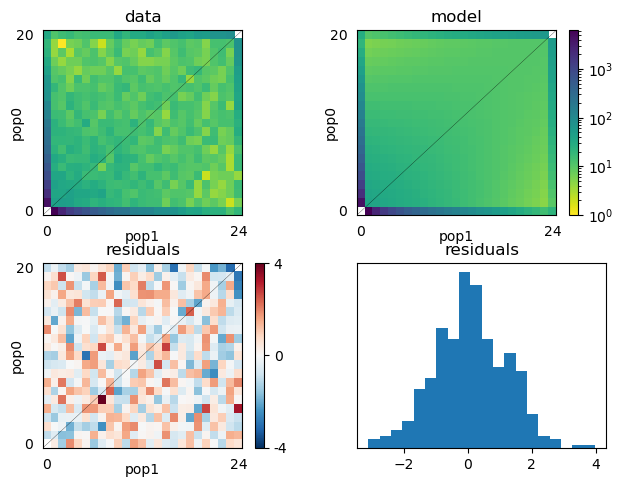

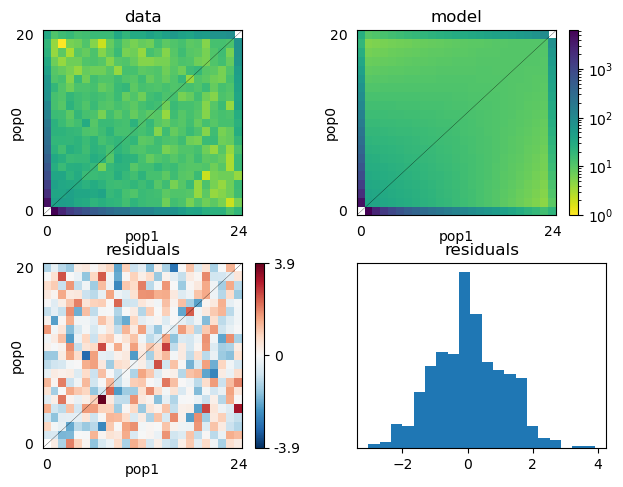

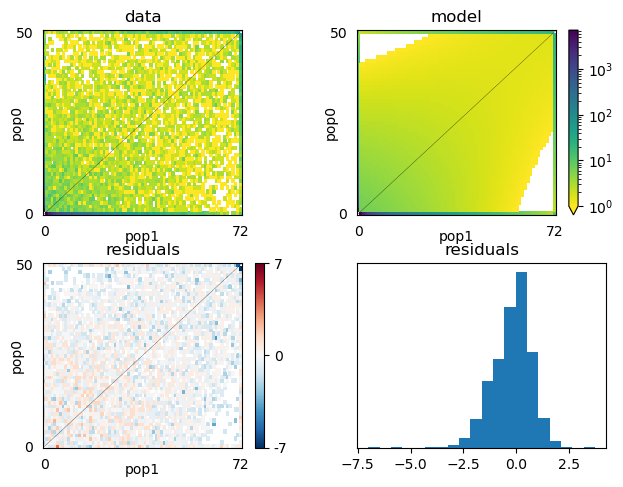

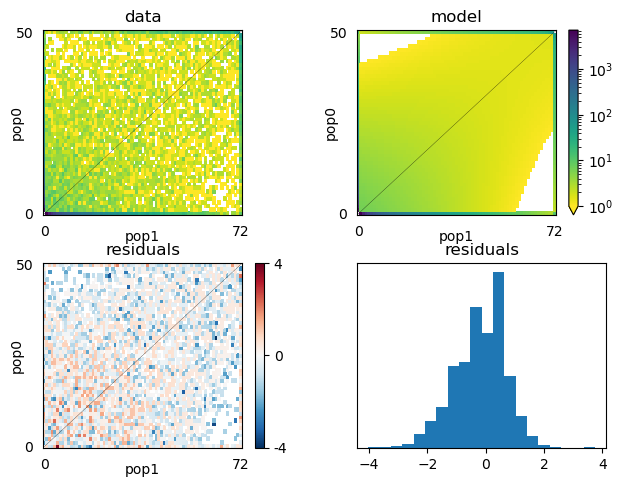

In [6]:
small_misid_params =[0.09328030358649048, 0.3052119929600469, 0.35369792553523965, 0.9126679469402572, 0.9571998706020125, 0.006279302246852359, 5056.596464091359]

small_params = [0.001, 0.38254488589562796, 0.33232021549720364, 0.8993562859341832, 0.9253642568998377, 5162.701330207154]

large_misid_params = [0.07032562240842663, 0.3165710294107673, 0.3494198747643816, 0.8453414002716074, 0.9324159064183527, 0.004785668770548594, 5143.235130822418]

large_params = [0.001, 0.37809704073237244, 0.3414002148381542, 0.8206236534294394, 0.9167763397510172, 5224.775820727579]

model = dadi.Polyploidy.auto_demographics.bottlegrowth_dip_size_change
model_ex = dadi.Numerics.make_extrap_func(model)

model_misid = dadi.Numerics.make_anc_state_misid_func(model)
model_misid_ex = dadi.Numerics.make_extrap_func(model_misid)

sfs_data_small = dadi.Spectrum.from_file("auto_small.sfs")
sfs_data_large = dadi.Spectrum.from_file("auto_large.sfs")

ns_small = sfs_data_small.sample_sizes
ns_large = sfs_data_large.sample_sizes

pts_small = [max(ns_small)+101, max(ns_small)+111, max(ns_small)+121]
pts_large = [max(ns_large)+101, max(ns_large)+111, max(ns_large)+121]

sfs_model_small = small_params[-1]*model_ex(small_params[:-1], ns_small, pts_small)
sfs_model_large = large_params[-1]*model_ex(large_params[:-1], ns_large, pts_large)

sfs_model_misid_small = small_misid_params[-1]*model_misid_ex(small_misid_params[:-1], ns_small, pts_small)
sfs_model_misid_large = large_misid_params[-1]*model_misid_ex(large_misid_params[:-1], ns_large, pts_large)

dadi.Plotting.plot_2d_comp_Poisson(sfs_model_small, sfs_data_small, vmin=1, show=True) 
dadi.Plotting.plot_2d_comp_Poisson(sfs_model_misid_small, sfs_data_small, vmin=1, show=True)

dadi.Plotting.plot_2d_comp_Poisson(sfs_model_large, sfs_data_large, vmin=1, show=True)
dadi.Plotting.plot_2d_comp_Poisson(sfs_model_misid_large, sfs_data_large, vmin=1, show=True)

In [10]:
# b_value computations

# true model
true_params = [0.15, 0.15, .3, .7, .8]
theta = 161744 * 4 * 5e6 * 7e-9 / 3.5

true_small = theta * model_ex(true_params, ns_small, pts_small)

true_large = theta * model_ex(true_params, ns_large, pts_large)

# pi values for tetraploids
pi_small = true_small.marginalize([0]).pi()
print(pi_small)
pi_large = true_large.marginalize([0]).pi()
print(pi_large)

# empirical b values
pi_small_emp = sfs_data_small.marginalize([0]).pi()
pi_large_emp = sfs_data_large.marginalize([0]).pi()

b_small = pi_small_emp / pi_small
print(b_small)
b_large = pi_large_emp / pi_large
print(b_large)

6311.710395603597
6312.161373378455
0.8304318993825869
0.8313829211214491
